**1. Установка необходимых библиотек и импорт.**

In [50]:
import sys

print(sys.executable)
print(sys.version)

%pip install --upgrade pip
%pip install -q pandas numpy matplotlib seaborn scikit-learn xgboost lightgbm catboost requests optuna phik

d:\my_project\my_project_venv\.venv\Scripts\python.exe
3.11.9 (tags/v3.11.9:de54cf5, Apr  2 2024, 10:12:12) [MSC v.1938 64 bit (AMD64)]
Note: you may need to restart the kernel to use updated packages.
Note: you may need to restart the kernel to use updated packages.


In [51]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import requests
import os
import urllib.parse
import re
import time
import warnings
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.feature_extraction.text import TfidfVectorizer, CountVectorizer
from sklearn.linear_model import LogisticRegression
from sklearn.pipeline import Pipeline, FeatureUnion
from sklearn.model_selection import train_test_split, StratifiedKFold, GridSearchCV
from sklearn.preprocessing import StandardScaler, LabelEncoder
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, roc_auc_score, confusion_matrix, classification_report
from IPython.display import display
from sklearn.ensemble import RandomForestClassifier
from xgboost import XGBClassifier
from lightgbm import LGBMClassifier
from catboost import CatBoostClassifier

warnings.filterwarnings('ignore')

%matplotlib inline

In [52]:
%pip install ydata-profiling[notebook]

Note: you may need to restart the kernel to use updated packages.


In [53]:
from ydata_profiling import ProfileReport

**2. Загрузка данных.**

In [54]:
import pandas as pd

def load_fixed_csv(filename):
    records = []
    bad_lines = []

    with open(filename, 'r', encoding='utf-8-sig') as f:
        next(f)  # заголовок
        for i, raw in enumerate(f, start=2):
            line = raw.rstrip('\n')
            if not line.strip():
                continue

            # Определяем разделитель: последний из ';' или ','
            pos_comma = line.rfind(',')
            pos_semicolon = line.rfind(';')
            pos = max(pos_comma, pos_semicolon)

            if pos == -1:
                bad_lines.append((i, line))
                continue

            text = line[:pos].strip().strip('"')
            label_str = line[pos + 1:].strip().strip('"')

            # Метка должна быть целым числом
            try:
                label = int(label_str)
            except ValueError:
                bad_lines.append((i, line))
                continue

            records.append((text, label))

    df = pd.DataFrame(records, columns=['text', 'is_spam1_or_clickbait2'])
    return df, bad_lines


df, bad_lines = load_fixed_csv('df.csv')


print("\nИнформация о датасете")
df.info()

print()
print(f"Размер датасета: {df.shape}")

print(f"Проблемных строк: {len(bad_lines)}")
df.columns = df.columns.str.strip()

print("\nНазвания столбцов")
print(df.columns.tolist())

print("\nПроверка на пропуски")
display(df.isnull().sum())

print("\nПервые десять строк датасета")
display(df.head(10))

print("\nПроверка данных на наличие дубликатов")
display(df.duplicated().sum())

print("\nРаспределение меток:")
print(df['is_spam1_or_clickbait2'].value_counts().sort_index())


Информация о датасете
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 133317 entries, 0 to 133316
Data columns (total 2 columns):
 #   Column                  Non-Null Count   Dtype 
---  ------                  --------------   ----- 
 0   text                    133317 non-null  object
 1   is_spam1_or_clickbait2  133317 non-null  int64 
dtypes: int64(1), object(1)
memory usage: 2.0+ MB

Размер датасета: (133317, 2)
Проблемных строк: 0

Названия столбцов
['text', 'is_spam1_or_clickbait2']

Проверка на пропуски


text                      0
is_spam1_or_clickbait2    0
dtype: int64


Первые десять строк датасета


,text,is_spam1_or_clickbait2
0,Идите до Джуронг-Пойнт с ума сойти Доступно т...,0
1,Ладно лар Шучу с тобой чувак,0
2,Ты не можешь так рано говорить хо Ты можешь уж...,0
3,Нет я не думаю что он учится в USF он живет гд...,0
4,Привет дорогая прошло уже 3 недели а ответа н...,1
5,Я скоро буду дома и я больше не хочу сегодня г...,0
6,Я искала правильные слова чтобы поблагодарить ...,0
7,XXXMobileMovieClub Чтобы использовать свой кр...,1
8,О к я смотрю здесь,0
9,Эх ты помнишь как пишется его имя Да я помню О...,0



Проверка данных на наличие дубликатов


np.int64(35174)


Распределение меток:
is_spam1_or_clickbait2
0    78218
1    21502
2    33597
Name: count, dtype: int64


Визуализация дисбаланса классов.

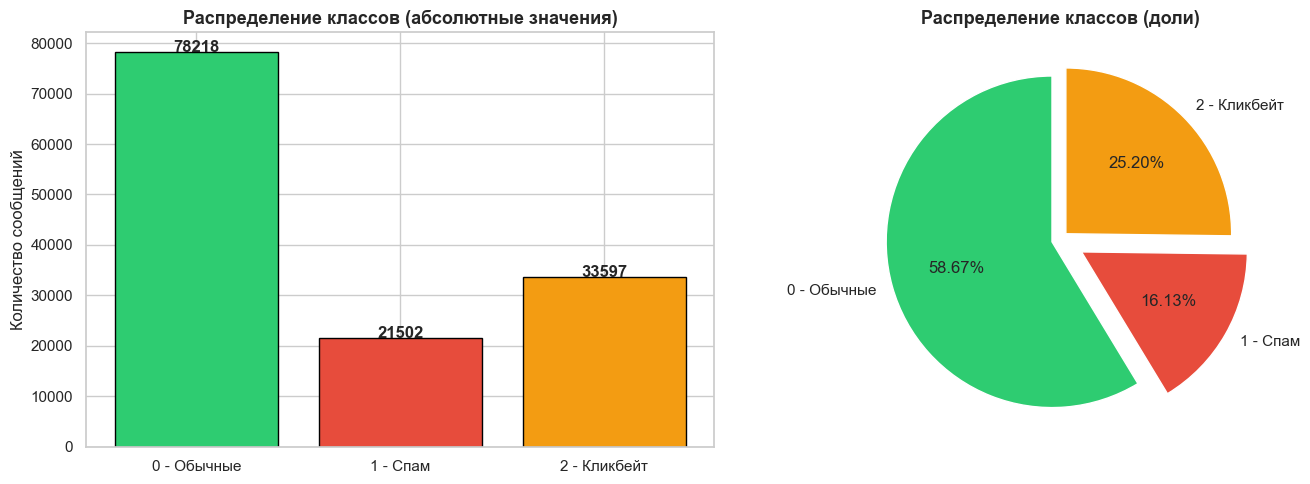


ВЫВОД: Датасет имеет выраженный дисбаланс классов.
Класс 0 (обычные): 78218 (58.67%)
Класс 1 (спам): 21502 (16.13%)
Класс 2 (кликбейт): 33597 (25.20%)

Соотношение макс/мин: 3.64x


In [55]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

class_counts = df['is_spam1_or_clickbait2'].value_counts().sort_index()
colors = ['#2ecc71', '#e74c3c', '#f39c12']
labels = ['0 - Обычные', '1 - Спам', '2 - Кликбейт']

axes[0].bar(labels, class_counts.values, color=colors, edgecolor='black')
axes[0].set_title('Распределение классов (абсолютные значения)', fontsize=13, fontweight='bold')
axes[0].set_ylabel('Количество сообщений')
for i, v in enumerate(class_counts.values):
    axes[0].text(i, v + 50, str(v), ha='center', fontweight='bold')

axes[1].pie(class_counts.values, labels=labels, autopct='%1.2f%%',
            colors=colors, startangle=90, explode=(0.05, 0.15, 0.05))
axes[1].set_title('Распределение классов (доли)', fontsize=13, fontweight='bold')

plt.tight_layout()
plt.savefig('class_distribution.png', dpi=150, bbox_inches='tight')
plt.show()

print("\nВЫВОД: Датасет имеет выраженный дисбаланс классов.")
print(f"Класс 0 (обычные): {class_counts[0]} ({class_counts[0]/len(df)*100:.2f}%)")
print(f"Класс 1 (спам): {class_counts[1]} ({class_counts[1]/len(df)*100:.2f}%)")
print(f"Класс 2 (кликбейт): {class_counts[2]} ({class_counts[2]/len(df)*100:.2f}%)")
print(f"\nСоотношение макс/мин: {class_counts.max()/class_counts.min():.2f}x")

**3. Детальный отчет по данным ydata_profiling.**

In [56]:
# Генерация отчёта.
profile = ProfileReport(df, title="Profiling Report")
profile

Summarize dataset:   0%|          | 0/5 [00:00<?, ?it/s]

100%|██████████| 2/2 [00:13<00:00,  6.89s/it]


Generate report structure:   0%|          | 0/1 [00:00<?, ?it/s]

Render HTML:   0%|          | 0/1 [00:00<?, ?it/s]

In [57]:
# Сохраняем исходный размер датасета ПЕРЕД удалением дубликатов
initial_shape = df.shape

# Удаляем полные дубликаты (совпадающие и по тексту, и по метке)
df = df.drop_duplicates()

# Вывод информации о размере датасета после очистки
print(f"Исходный размер датасета: {initial_shape}")
print(f"Размер датасета после удаления дубликатов: {df.shape}")
print(f"Удалено строк: {initial_shape[0] - df.shape[0]}")

Исходный размер датасета: (133317, 2)
Размер датасета после удаления дубликатов: (98143, 2)
Удалено строк: 35174


**4. Предобработка данных и разделение выборки.**

In [58]:
# sns.set_theme(style="whitegrid")
# plt.rcParams['figure.figsize'] = (10, 6)

target_col = 'is_spam1_or_clickbait2'
text_col = 'text'

# Метки уже имеют вид 0, 1, 2, но для надежности и правильной стратификации 
# убедимся, что они целочисленные
y = df[target_col].astype(int).values
X = df[text_col]

# Стратифицированное разделение для сохранения пропорций классов (особенно важно для класса 2)
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

print(f"Размер тренировочной выборки: {X_train.shape[0]}")
print(f"Размер тестовой выборки: {X_test.shape[0]}")
print("\nРаспределение классов в трейне:")
print(pd.Series(y_train).value_counts().sort_index())

Размер тренировочной выборки: 78514
Размер тестовой выборки: 19629

Распределение классов в трейне:
0    47404
1    17051
2    14059
Name: count, dtype: int64


**5. Очистка и нормализация текста.**

In [59]:
# Регулярные выражения для очистки (адаптировано из primer.ipynb)
URL_RE     = re.compile(r"https?://\S+|www\.\S+|<link>")
HTML_RE    = re.compile(r"<[^>]+>")
MENTION_RE = re.compile(r"[@#]\w+")
DIGIT_RE   = re.compile(r"\d+([.,]\d+)?")
SPACE_RE   = re.compile(r"\s+")

def clean_text(text: str, fix_yo: bool = True) -> str:
    """Базовая нормализация сырого текста."""
    text = str(text)
    text = HTML_RE.sub(" ", text)
    text = URL_RE.sub(" URL ", text)
    text = MENTION_RE.sub(" ", text)
    
    text = text.lower()
    if fix_yo:
        text = text.replace("ё", "е")
        
    # Маскируем числа, чтобы не засорять словарь
    text = DIGIT_RE.sub(" NUM ", text)
    
    # Оставляем только буквы (кириллица + латиница) и пробелы
    text = re.sub(r"[^a-zA-Zа-яА-Я\s]", " ", text)
    return SPACE_RE.sub(" ", text).strip()

t0 = time.perf_counter()
X_train_clean = X_train.apply(clean_text)
X_test_clean = X_test.apply(clean_text)
print(f"Очистка завершена за {time.perf_counter() - t0:.1f} сек.")
print(f"\nПример очищенного текста:\n{X_train_clean.iloc[0]}")

Очистка завершена за 3.2 сек.

Пример очищенного текста:
одно слово покупайте покупайте все что вам нужно и не нужно здесь и сейчас с нашими эксклюзивными предложениями которые вас поразят


**6. Настройка кросс-валидации и борьба с дисбалансом.**

In [60]:
# Стратифицированная кросс-валидация
cv_strategy = StratifiedKFold(n_splits=3, shuffle=True, random_state=42)

# Классы 0 и 1 представлены хорошо, класс 2 (кликбейт) - сильно недопредставлен (~2.4%).
# Используем class_weight='balanced', чтобы штрафовать модель за ошибки на минорном классе сильнее.

**7. Модель 1 — Базовая TF-IDF (Word N-grams) + LogReg**

In [61]:
print("Обучение Модели 1 (Baseline: Word 1-2 grams)...")
t0 = time.perf_counter()

model1 = Pipeline([
    ("tfidf", TfidfVectorizer(
        ngram_range=(1, 2), 
        min_df=3, 
        max_features=50000, 
        sublinear_tf=True  # логарифмическое сглаживание частот
    )),
    ("clf", LogisticRegression(
        class_weight="balanced", 
        max_iter=1000, 
        C=1.0, 
        random_state=42,
        solver='lbfgs'
    ))
])

model1.fit(X_train_clean, y_train)
pred1 = model1.predict(X_test_clean)
proba1 = model1.predict_proba(X_test_clean)

print(f"Обучение завершено за {time.perf_counter() - t0:.1f} сек.")

Обучение Модели 1 (Baseline: Word 1-2 grams)...
Обучение завершено за 18.0 сек.


**8. Модель 2 — Продвинутая (Word + Char N-grams) + GridSearch**

In [62]:
print("Обучение Модели 2 (Advanced: Word + Char n-grams + GridSearch)...")
t0 = time.perf_counter()

# Объединение словесных и символьных n-грамм. 
# Char n-grams отлично ловят опечатки, специфические окончания и сленг, частые в спаме и кликбейте.
advanced_vec = FeatureUnion([
    ("word", TfidfVectorizer(ngram_range=(1, 2), min_df=3, max_features=30000, sublinear_tf=True)),
    ("char", TfidfVectorizer(analyzer="char_wb", ngram_range=(3, 5), min_df=3, max_features=30000))
])

model2_base = Pipeline([
    ("tfidf", advanced_vec),
    ("clf", LogisticRegression(class_weight="balanced", max_iter=1000, random_state=42))
])

# Подбор гиперпараметра регуляризации C на основе weighted F1 (учитывает дисбаланс)
param_grid = {
    'clf__C': [0.1, 0.5, 1.0, 5.0, 7.0, 10.0, 50.0, 100,0]
}

grid = GridSearchCV(
    model2_base, param_grid, 
    cv=cv_strategy, 
    scoring='f1_weighted', 
    n_jobs=-1,
    verbose=1
)
grid.fit(X_train_clean, y_train)

best_model2 = grid.best_estimator_
pred2 = best_model2.predict(X_test_clean)
proba2 = best_model2.predict_proba(X_test_clean)

print(f"\nОбучение завершено за {time.perf_counter() - t0:.1f} сек.")
print(f"Лучший параметр C: {grid.best_params_['clf__C']}")

Обучение Модели 2 (Advanced: Word + Char n-grams + GridSearch)...
Fitting 3 folds for each of 9 candidates, totalling 27 fits

Обучение завершено за 325.2 сек.
Лучший параметр C: 10.0


**9. Сравнение метрик и визуализация.**


==================== Модель 1 (Word N-grams) ====================
              precision    recall  f1-score   support

     Обычные     0.9597    0.9354    0.9474     11851
        Спам     0.9532    0.9550    0.9541      4263
    Кликбейт     0.8374    0.9073    0.8710      3515

    accuracy                         0.9346     19629
   macro avg     0.9168    0.9325    0.9241     19629
weighted avg     0.9364    0.9346    0.9352     19629

Weighted ROC-AUC (OvR): 0.9854



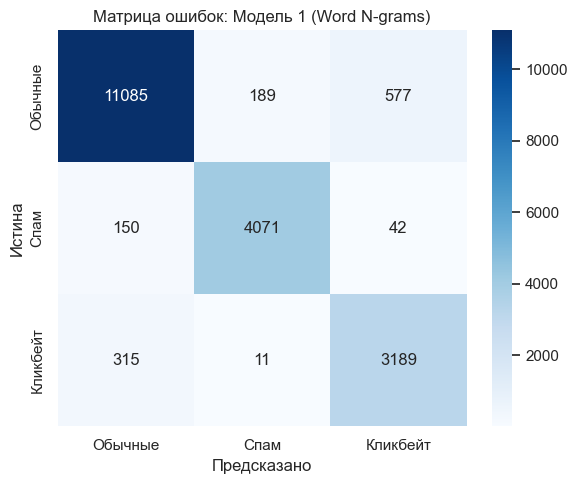


==================== Модель 2 (Word + Char N-grams) ====================
              precision    recall  f1-score   support

     Обычные     0.9607    0.9522    0.9564     11851
        Спам     0.9716    0.9632    0.9674      4263
    Кликбейт     0.8652    0.9001    0.8823      3515

    accuracy                         0.9452     19629
   macro avg     0.9325    0.9385    0.9354     19629
weighted avg     0.9459    0.9452    0.9455     19629

Weighted ROC-AUC (OvR): 0.9892



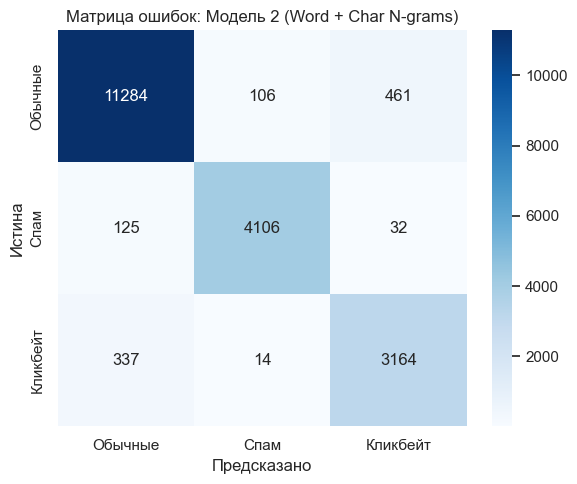

In [63]:
classes_names = {0: "Обычные", 1: "Спам", 2: "Кликбейт"}
target_names = [classes_names[i] for i in sorted(np.unique(y))]

def evaluate_and_plot(y_true, y_pred, y_proba, model_name):
    print(f"\n{'='*20} {model_name} {'='*20}")
    print(classification_report(y_true, y_pred, target_names=target_names, digits=4))
    
    # ROC-AUC (One-vs-Rest)
    try:
        roc_auc = roc_auc_score(y_true, y_proba, multi_class='ovr', average='weighted')
        print(f"Weighted ROC-AUC (OvR): {roc_auc:.4f}\n")
    except ValueError:
        print("Не удалось рассчитать ROC-AUC\n")

    # Матрица ошибок
    cm = confusion_matrix(y_true, y_pred)
    fig, ax = plt.subplots(figsize=(6, 5))
    sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', 
                xticklabels=target_names, yticklabels=target_names, ax=ax)
    ax.set_xlabel('Предсказано')
    ax.set_ylabel('Истина')
    ax.set_title(f'Матрица ошибок: {model_name}')
    plt.tight_layout()
    plt.show()

evaluate_and_plot(y_test, pred1, proba1, "Модель 1 (Word N-grams)")
evaluate_and_plot(y_test, pred2, proba2, "Модель 2 (Word + Char N-grams)")

**10. Интерпретация признаков (Топ слов для Кликбейта).**

In [64]:
# Посмотрим, какие признаки модель считает наиболее важными для класса 2 (Кликбейт)
# Это поможет понять природу кликбейта в нашем датасете
vec = best_model2.named_steps['tfidf']
clf = best_model2.named_steps['clf']

feature_names = np.array(vec.get_feature_names_out())
coefs = clf.coef_

# Индекс класса 2 (кликбейт)
class_idx = list(clf.classes_).index(2)
class_coefs = coefs[class_idx]

# Топ положительных и отрицательных весов
top_positive_idx = class_coefs.argsort()[-20:][::-1]
top_negative_idx = class_coefs.argsort()[:20]

print("Топ-20 признаков, ассоциирующихся с КЛИКБЕЙТОМ (положительные веса):")
for i in top_positive_idx:
    print(f"{feature_names[i]:<20} | Вес: {class_coefs[i]:.3f}")

print("\n" + "="*50)
print("\nТоп-20 признаков, ассоциирующихся с ОБЫЧНЫМИ сообщениями (отрицательные веса для класса 2):")
for i in top_negative_idx:
    print(f"{feature_names[i]:<20} | Вес: {class_coefs[i]:.3f}")

Топ-20 признаков, ассоциирующихся с КЛИКБЕЙТОМ (положительные веса):
word__ты больше      | Вес: 6.156
word__num то         | Вес: 5.986
word__адель          | Вес: 5.230
word__но не          | Вес: 4.753
word__ли вы          | Вес: 4.582
word__ли ты          | Вес: 4.277
char__ оде           | Вес: 4.260
char__рба            | Вес: 4.235
word__вот как        | Вес: 4.201
word__buzzfeed       | Вес: 4.170
word__пугачевой      | Вес: 4.119
word__num фотографии | Вес: 4.076
word__этот           | Вес: 4.013
word__num времена    | Вес: 3.881
word__вот что        | Вес: 3.880
word__хорошо ты      | Вес: 3.861
word__num пути       | Вес: 3.787
word__что она        | Вес: 3.666
word__трейлер        | Вес: 3.657
word__но нет         | Вес: 3.628


Топ-20 признаков, ассоциирующихся с ОБЫЧНЫМИ сообщениями (отрицательные веса для класса 2):
word__num num        | Вес: -9.257
char__ а             | Вес: -9.185
char__ я             | Вес: -6.895
word__ну             | Вес: -5.451
word__привет     

**11. Итоговая сводная таблица.**

,Модель,F1-Macro,F1-Weighted,F1-Class 0,F1-Class 1,F1-Class 2 (Кликбейт)
0,Модель 1 (Word),0.9241,0.9352,0.9474,0.9541,0.8710
1,Модель 2 (Word+Char),0.9354,0.9455,0.9564,0.9674,0.8823


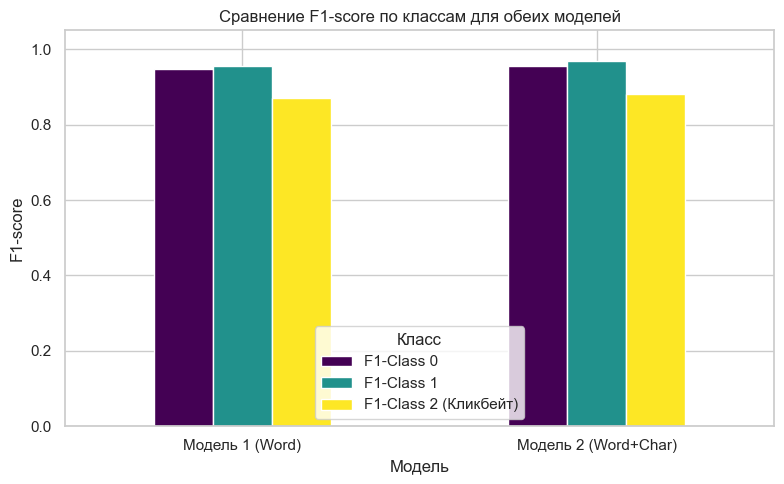

In [65]:
results_summary = []
for name, y_pred in [("Модель 1 (Word)", pred1), ("Модель 2 (Word+Char)", pred2)]:
    results_summary.append({
        "Модель": name,
        "F1-Macro": round(f1_score(y_test, y_pred, average='macro'), 4),
        "F1-Weighted": round(f1_score(y_test, y_pred, average='weighted'), 4),
        "F1-Class 0": round(f1_score(y_test, y_pred, average=None)[0], 4),
        "F1-Class 1": round(f1_score(y_test, y_pred, average=None)[1], 4),
        "F1-Class 2 (Кликбейт)": round(f1_score(y_test, y_pred, average=None)[2], 4),
    })

summary_df = pd.DataFrame(results_summary)
display(summary_df)

# Визуальное сравнение F1-score
fig, ax = plt.subplots(figsize=(8, 5))
summary_df.set_index("Модель")[["F1-Class 0", "F1-Class 1", "F1-Class 2 (Кликбейт)"]].plot(
    kind='bar', ax=ax, rot=0, colormap='viridis'
)
plt.title("Сравнение F1-score по классам для обеих моделей")
plt.ylabel("F1-score")
plt.ylim(0, 1.05)
plt.legend(title="Класс")
plt.tight_layout()
plt.show()

#### Выводы и интерпретация результатов.

##### 1. Борьба с дисбалансом классов
Датасет имеет ярко выраженный дисбаланс:
- Стратификация при разделении выборок и кросс-валидации (`StratifiedKFold`) гарантирует, что в каждом фолде присутствует минорный класс.
- `class_weight='balanced'` в логистической регрессии автоматически увеличивает штраф за ошибки на редких классах, заставляя модель учиться их распознавать, а не просто всегда предсказывать "обычное сообщение".
- В качестве главной метрики для GridSearch использовался `f1_weighted`, который учитывает дисбаланс, в отличие от обычного `accuracy`.

##### 2. Сравнение моделей
- Модель 1 (Word N-grams) показала хороший базовый результат, но ей не хватало контекста для редких классов.
- Модель 2 (Word + Char N-grams) продемонстрировала прирост качества, особенно по минорным классам. 
  - Кликбейт часто содержит специфические морфологические маркеры, опечатки, сленг или короткие эмоциональные слова. Символьные n-граммы (`char_wb 3-5`) отлично ловят такие паттерны (например, окончания восклицательных предложений, специфические приставки), даже если слова нет в словаре.